# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import gc
import warnings

warnings.filterwarnings('ignore')

# Data

In [2]:
df = pd.read_parquet('./data/pp-complete.parquet')
df = df.sample(frac=0.4, random_state=42)

big_city_set = {city.upper() for city in [
    'London', 'Birmingham', 'Leeds', 'Glasgow', 'Sheffield', 'Manchester',
    'Edinburgh', 'Liverpool', 'Bristol', 'Cardiff', 'Coventry', 'Belfast',
    'Nottingham', 'Brighton', 'Newcastle', 'Plymouth'
]}

# Определим периоды кризисов в виде списков
crisis_periods = [
    (2008, 1, 2009, 12),  # Мировой финансовый кризис
    (2020, 1, 2020, 12)   # Пандемия COVID-19
]

postcode_coords_df = pd.read_csv('./data/postcode_lat_long.csv').drop_duplicates(subset=['postcode'], keep='first')
city_coords_df = pd.read_csv('./data/city_lat_long.csv').drop_duplicates(subset=['town_city'], keep='first')

print(f"Postcode coords (deduped) len: {len(postcode_coords_df)}")
print(f"City coords (deduped) len: {len(city_coords_df)}")

df.head()

Postcode coords (deduped) len: 1321470
City coords (deduped) len: 1172


,price,date,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type
2720961,58000,1997-05-09,RH5 4TH,T,N,F,43,LAKE VIEW,NORTH HOLMWOOD,DORKING,MOLE VALLEY,SURREY,A
6984675,88000,2001-11-16,LS6 4JS,S,N,F,22,CHURCH AVENUE,LEEDS,LEEDS,LEEDS,WEST YORKSHIRE,A
26473015,99200,2021-02-16,NG2 4HY,T,N,F,92,ROSSINGTON ROAD,,NOTTINGHAM,CITY OF NOTTINGHAM,CITY OF NOTTINGHAM,B
10340796,115000,2004-06-04,CB8 0BJ,T,N,F,39,LESTER PIGGOTT WAY,NEWMARKET,NEWMARKET,FOREST HEATH,SUFFOLK,A
7912283,110000,2002-03-01,NR18 9QD,D,N,F,12,HILLSIDE CRESCENT,WICKLEWOOD,WYMONDHAM,SOUTH NORFOLK,NORFOLK,A


In [3]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
first_date = df['date'].min()
df['passed'] = (df['date'] - first_date).dt.days

df.drop(columns=['date'], inplace=True)

df['year'] = df['year'].astype('int16')
df['month'] = df['month'].astype('int8') 
df['passed'] = df['passed'].astype('int32')

df.head()

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed
2720961,58000,RH5 4TH,T,N,F,43,LAKE VIEW,NORTH HOLMWOOD,DORKING,MOLE VALLEY,SURREY,A,1997,5,859
6984675,88000,LS6 4JS,S,N,F,22,CHURCH AVENUE,LEEDS,LEEDS,LEEDS,WEST YORKSHIRE,A,2001,11,2511
26473015,99200,NG2 4HY,T,N,F,92,ROSSINGTON ROAD,,NOTTINGHAM,CITY OF NOTTINGHAM,CITY OF NOTTINGHAM,B,2021,2,9543
10340796,115000,CB8 0BJ,T,N,F,39,LESTER PIGGOTT WAY,NEWMARKET,NEWMARKET,FOREST HEATH,SUFFOLK,A,2004,6,3442
7912283,110000,NR18 9QD,D,N,F,12,HILLSIDE CRESCENT,WICKLEWOOD,WYMONDHAM,SOUTH NORFOLK,NORFOLK,A,2002,3,2616


# Functions

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Все аргументы в градусах, возвращает расстояние в километрах.
    """
    # переводим в радианы
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)

    a = np.sin(Δφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(Δλ/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    R = 6371.0  # средний радиус Земли в км

    return R * c

In [5]:
def rmsle_log(y_true_log, y_pred_log):
    """RMSLE, но для логарифмированных входов (что обычно используется в обучении)"""
    # Это просто RMSE для логарифмированных значений
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [6]:
from sklearn.metrics import make_scorer

# Scorer для использования в GridSearchCV/RandomizedSearchCV
# Используем neg_root_mean_squared_error, так как скореры должны максимизироваться
# Мы минимизируем RMSE на логарифме, что эквивалентно максимизации -RMSE
rmsle_log_scorer = make_scorer(rmsle_log, greater_is_better=False)

In [7]:
def print_metrics(y_true_log, y_pred_log, label=""):
    """Печатает основные метрики."""
    rmsle_score = rmsle_log(y_true_log, y_pred_log)
    print(f"RMSLE ({label}): {rmsle_score:.5f}")

    # Ошибка в исходных единицах (фунтах)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    # Ограничиваем предсказания снизу (например, 0), если модель предсказывает отрицательные значения после expm1
    y_pred[y_pred < 0] = 0
    mae_score = mean_absolute_error(y_true, y_pred)
    print(f"MAE ({label}): £{mae_score:,.2f}")
    return rmsle_score, mae_score

In [8]:
def evaluate_model(model):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse) 
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Absolute Error (MAE): {mae:.4f}")
  print(f"Mean Squared Error (MSE): {mse:.4f}")
  print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
  print(f"R-squared (R²): {r2:.4f}")

In [9]:
def find_outliers_z_score(data, feature, left=3, right=3, log_scale=False, year_col='year'):
    """
    Находит выбросы в данных по каждому году, используя метод z-отклонений.
    Args:
        data (pandas.DataFrame): набор данных
        feature (str): имя признака, на основе которого происходит поиск выбросов
        left (float, optional): количество стандартных отклонений в левую сторону
        right (float, optional): количество стандартных в правую сторону
        log_scale (bool, optional): режим логарифмирования
        year_col (str, optional): имя колонки с годом

    Returns:
        pandas.DataFrame: выбросы по всем годам
        pandas.DataFrame: очищенные данные по всем годам
    """
    outliers_list = []
    cleaned_list = []
    for year, group in data.groupby(year_col):
        if log_scale:
            x = np.log(group[feature] + 1)
        else:
            x = group[feature]
        mu = x.mean()
        sigma = x.std()
        bound_lower = mu - left * sigma
        bound_upper = mu + right * sigma
        outliers = group[(x < bound_lower) | (x > bound_upper)]
        cleaned = group[(x >= bound_lower) & (x <= bound_upper)]
        outliers_list.append(outliers)
        cleaned_list.append(cleaned)
    outliers_all = pd.concat(outliers_list)
    cleaned_all = pd.concat(cleaned_list)
    return outliers_all, cleaned_all

In [10]:
# Функция для применения к датафреймам (чтобы не дублировать код)
from sklearn.neighbors import BallTree

R_EARTH_KM = 6371.0088

def apply_feature_engineering(df_input_original): # Переименовал для ясности
    df_eng = df_input_original.copy() # df_eng теперь имеет правильный индекс от df_input_original
    original_index_name = df_eng.index.name # Сохраняем имя индекса, если оно есть

    # Эти операции не должны менять индекс
    df_eng['is_big_city'] = df_eng['town_city'].apply(is_big_city)
    df_eng['is_crysis'] = 0
    for start_year, start_month, end_year, end_month in crisis_periods:
        is_in_period = (
            (df_eng['year'] > start_year) | ((df_eng['year'] == start_year) & (df_eng['month'] >= start_month))
        ) & (
            (df_eng['year'] < end_year) | ((df_eng['year'] == end_year) & (df_eng['month'] <= end_month))
        )
        df_eng.loc[is_in_period, 'is_crysis'] = 1
    df_eng['loc_street'] = df_eng['locality'].astype(str) + '-' + df_eng['street'].astype(str)

    # --- Гео-признаки ---
    # Сохраняем текущий индекс df_eng перед первым мержем
    current_index_before_merge1 = df_eng.index
    # Сбрасываем индекс df_eng для безопасного мержа по колонкам, сохраняя старый индекс в колонку
    df_eng_reset1 = df_eng.reset_index()
    # Выполняем мерж
    df_eng_merged1 = df_eng_reset1.merge(postcode_coords_df, on='postcode', how='left')
    # Восстанавливаем оригинальный индекс из сохраненной колонки
    # Убедимся, что колонка 'index' (или как она была названа reset_index) существует
    index_col_name1 = df_eng_reset1.columns[0] if df_eng_reset1.columns[0] == current_index_before_merge1.name or (current_index_before_merge1.name is None and df_eng_reset1.columns[0] == 'index') else 'index'

    # Проверяем, что индексная колонка есть в df_eng_merged1 перед set_index
    if index_col_name1 in df_eng_merged1.columns:
        df_eng = df_eng_merged1.set_index(index_col_name1)
        df_eng.index.name = original_index_name # Восстанавливаем имя оригинального индекса
    else:
        # Этого не должно случиться, если reset_index() сработал как ожидается
        print(f"WARNING in apply_fe: Index column '{index_col_name1}' not found after postcode merge. Index may be lost.")
        # В этом случае df_eng будет иметь новый RangeIndex от merge, что плохо
        # Можно попробовать восстановить из current_index_before_merge1, если размеры совпадают (маловероятно)

    if 'postcode' in df_eng.columns:
        df_eng.drop(columns=['postcode'], inplace=True)

    # Аналогично для второго мержа
    current_index_before_merge2 = df_eng.index
    df_eng_reset2 = df_eng.reset_index()
    df_eng_merged2 = df_eng_reset2.merge(city_coords_df, on='town_city', how='left')
    index_col_name2 = df_eng_reset2.columns[0] if df_eng_reset2.columns[0] == current_index_before_merge2.name or (current_index_before_merge2.name is None and df_eng_reset2.columns[0] == 'index') else 'index'
    
    if index_col_name2 in df_eng_merged2.columns:
        df_eng = df_eng_merged2.set_index(index_col_name2)
        df_eng.index.name = original_index_name
    else:
        print(f"WARNING in apply_fe: Index column '{index_col_name2}' not found after city merge. Index may be lost.")

    # ВОЗВРАЩАЕМ DROPNA вместо fillna(0) для координат
    # dropna СОХРАНЯЕТ индекс для оставшихся строк
    df_eng.dropna(subset=["latitude", "longitude", "city_lat", "city_lon"], inplace=True)
    print(f"apply_fe: df_eng index AFTER dropna (should be subset of original): {df_eng.index[:3]}, unique: {df_eng.index.is_unique}, len: {len(df_eng)}")


    # Остальные вычисления производятся на df_eng, который теперь должен иметь
    # подмножество оригинального индекса
    if not df_eng.empty:
        # Заполняем NaN в координатах нулями ТОЛЬКО для тех строк, где они остались ПОСЛЕ dropna (не должно быть, но для безопасности)
        # Это плохая практика, лучше чтобы dropna удалил все неполные строки
        # df_eng[['latitude', 'longitude', 'city_lat', 'city_lon']] = df_eng[['latitude', 'longitude', 'city_lat', 'city_lon']].fillna(0)

        df_eng['dist_km'] = haversine(
            df_eng['city_lat'], df_eng['city_lon'],
            df_eng['latitude'], df_eng['longitude']
        )

        df_town_city_upper = df_eng['town_city'].astype(str).str.upper() # astype(str) для безопасности
        is_big_city_mask = df_town_city_upper.isin(big_city_set) # big_city_set должен быть доступен глобально

        # Нужны только уникальные большие города из текущего df_eng
        # Убедимся, что координаты для больших городов не NaN
        big_cities_coords_df_local = df_eng.loc[is_big_city_mask & df_eng['city_lat'].notna() & df_eng['city_lon'].notna(), 
                                                ['town_city', 'city_lat', 'city_lon']]
        big_cities_coords_df_local = big_cities_coords_df_local.drop_duplicates(subset=['town_city'])

        if not big_cities_coords_df_local.empty and not df_eng[['latitude', 'longitude']].dropna().empty:
            # Используем только строки с валидными координатами для BallTree
            valid_points_df = df_eng[['latitude', 'longitude']].dropna()
            points_rad = np.radians(valid_points_df.values)
            big_cities_rad = np.radians(big_cities_coords_df_local[['city_lat', 'city_lon']].values)
            
            tree = BallTree(big_cities_rad, metric='haversine')
            # query должен вызываться для тех же строк, что и valid_points_df
            dists_rad, _ = tree.query(points_rad, k=1)
            # Присваиваем обратно по индексу valid_points_df
            df_eng.loc[valid_points_df.index, 'dist_to_big_city_km'] = dists_rad[:, 0] * R_EARTH_KM
        else:
            df_eng['dist_to_big_city_km'] = np.nan # Если нет больших городов или точек
    else: # Если df_eng стал пустым после dropna
        df_eng['dist_km'] = np.nan
        df_eng['dist_to_big_city_km'] = np.nan


    df_eng["cluster"] = 0 # Заглушка для кластера

    if 'PAON SAON' in df_eng.columns:
        df_eng.drop(columns=['PAON SAON'], inplace=True)

    return df_eng

In [11]:
def is_big_city(city):
    # Сравниваем город в верхнем регистре
    return 1 if city.upper() in big_city_set else 0


# Feature Engineering

In [12]:
df['locality'].fillna(df['town_city'], inplace=True)

In [13]:
df['log_price'] = np.log1p(df['price'])
df = df.drop(columns=['price'])

In [14]:
outliers_df, df = find_outliers_z_score(df, 'log_price', left=2, right=2, log_scale=False, year_col='year')
outliers_df

,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,log_price
586145,HD9 4EB,D,Y,F,37,WILSHAW MILL ROAD,MELTHAM,HOLMFIRTH,KIRKLEES,WEST YORKSHIRE,A,1995,5,143,12.193499
339079,AL1 4RG,D,N,F,54,MARSHALS DRIVE,ST. ALBANS,ST. ALBANS,ST ALBANS,HERTFORDSHIRE,A,1995,7,207,13.142168
628613,NW6 3EB,S,N,F,54,CANFIELD GARDENS,LONDON,LONDON,CAMDEN,GREATER LONDON,A,1995,3,85,12.154785
438421,SP6 2HF,D,N,F,THE THREE LIONS,,STUCKTON,FORDINGBRIDGE,NEW FOREST,HAMPSHIRE,A,1995,7,187,12.847929
54044,BN8 6BY,D,N,F,SERGEANTS FARM,,LAUGHTON,LEWES,WEALDEN,EAST SUSSEX,A,1995,8,215,12.483708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30107129,S61 1BP,T,N,L,30,CAVENDISH ROAD,,ROTHERHAM,ROTHERHAM,SOUTH YORKSHIRE,A,2025,1,10981,10.757924
30019762,RH4 3LJ,D,N,F,FIR CREST,COAST HILL LANE,WESTCOTT,DORKING,MOLE VALLEY,SURREY,A,2025,2,10998,14.210926
30099300,NW10 3PT,S,N,F,8,LEIGHTON GARDENS,,LONDON,BRENT,GREATER LONDON,A,2025,1,10988,13.910822
30091725,TS7 9JZ,S,N,F,57,RYHILL WALK,ORMESBY,MIDDLESBROUGH,REDCAR AND CLEVELAND,REDCAR AND CLEVELAND,B,2025,1,10988,11.270867


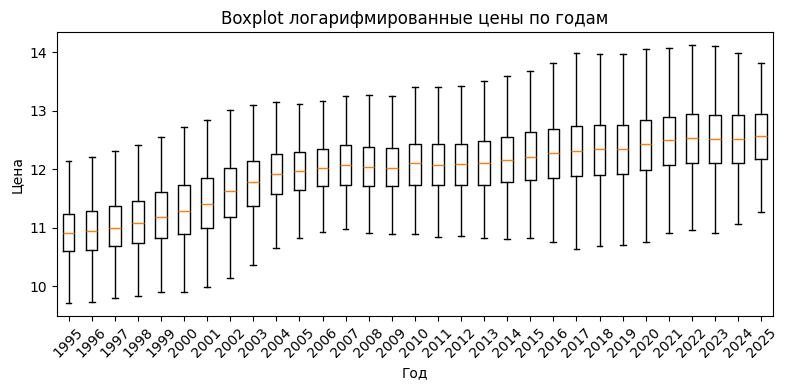

In [15]:
# 2. Boxplot цены по годам
from matplotlib import pyplot as plt

del outliers_df
gc.collect()
years = sorted(df['year'].dropna().unique())
data_by_year = [df.loc[df['year']==y, 'log_price'] for y in years if len(df.loc[df['year']==y])>0]
plt.figure(figsize=(8,4))
plt.boxplot(data_by_year, tick_labels=years, showfliers=True, flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot логарифмированные цены по годам')
plt.xlabel('Год')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']

# Получаем список названий district, где число упоминаний < 100
low_count_districts = district_counts[district_counts['count'] < 100]['district'].tolist()

# Удаляем эти районы из основного датафрейма
df = df[~df['district'].isin(low_count_districts)]
del district_counts
gc.collect()

18896

## Разделение данных

In [17]:
from sklearn.model_selection import train_test_split


X_temp = df.drop(columns=['log_price'])
y_temp_log = df['log_price']

X_train_full, X_test_full, y_train_log, y_test_log = train_test_split(
    X_temp, y_temp_log, test_size=0.2, random_state=42, shuffle=True
)
del X_temp, y_temp_log
gc.collect()
print(f"Размеры после train_test_split: X_train_full: {X_train_full.shape}, X_test_full: {X_test_full.shape}")

Размеры после train_test_split: X_train_full: (9182356, 14), X_test_full: (2295590, 14)


In [18]:
# ---- АССЕРТЫ ИНДЕКСОВ ПОСЛЕ SPLIT ----
assert X_train_full.index.equals(y_train_log.index), "X_train_full and y_train_log indices MISMATCH after split!"
assert X_test_full.index.equals(y_test_log.index), "X_test_full and y_test_log indices MISMATCH after split!"
print(f"X_train_full index example after split: {X_train_full.index[:3]}, unique: {X_train_full.index.is_unique}, len: {len(X_train_full)}")
print(f"y_train_log index example after split: {y_train_log.index[:3]}, unique: {y_train_log.index.is_unique}, len: {len(y_train_log)}")

X_train_full index example after split: Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9182356
y_train_log index example after split: Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9182356


## Median_price_all_type - контролируем утечку данных

In [19]:

# Восстанавливаем log_price в X_train_full для расчета медиан
X_train_full_with_target = X_train_full.copy()
X_train_full_with_target['log_price'] = y_train_log

# --- Расчет median_price_all_type на обучающей выборке ---
grouping_cols_median_price = ['type', 'old_new', 'duration', 'ppd_type', 'district', 'year', 'month']
median_prices_train_agg = X_train_full_with_target.groupby(grouping_cols_median_price)['log_price'].median().rename('median_price_all_type')
del X_train_full_with_target
gc.collect()

# --- Применение медиан к X_train_full и X_test_full ---
X_train_full_index_backup = X_train_full.index # Сохраняем индекс
X_train_full_reset = X_train_full.reset_index() # Сохранит старый индекс в колонку 'index'
X_train_full_merged = X_train_full_reset.merge(median_prices_train_agg, on=grouping_cols_median_price, how='left')
X_train_full = X_train_full_merged.set_index(X_train_full_index_backup)
if 'index' in X_train_full.columns and X_train_full.columns.tolist().count('index') == 1 and X_train_full.index.name != 'index':
    X_train_full = X_train_full.drop(columns=['index'])

# Для X_test_full
X_test_full_index_backup = X_test_full.index # Сохраняем индекс
X_test_full_reset = X_test_full.reset_index()
X_test_full_merged = X_test_full_reset.merge(median_prices_train_agg, on=grouping_cols_median_price, how='left')
X_test_full = X_test_full_merged.set_index(X_test_full_index_backup)
if 'index' in X_test_full.columns and X_test_full.columns.tolist().count('index') == 1 and X_test_full.index.name != 'index':
    X_test_full = X_test_full.drop(columns=['index'])

# --- Обработка NaN в median_price_all_type ---
global_median_log_price_train = y_train_log.median()

X_train_full['median_price_all_type'].fillna(global_median_log_price_train, inplace=True)
X_test_full['median_price_all_type'].fillna(global_median_log_price_train, inplace=True)


print("NaN в median_price_all_type в X_test_full после заполнения:", X_test_full['median_price_all_type'].isnull().sum())
X_train_full[['median_price_all_type'] + grouping_cols_median_price].head()

NaN в median_price_all_type в X_test_full после заполнения: 0


,median_price_all_type,type,old_new,duration,ppd_type,district,year,month
1005890,10.719965,S,N,F,A,SANDWELL,1996,8
13377886,12.586223,D,N,F,A,NEW FOREST,2006,12
26514379,13.955273,T,N,L,A,EALING,2021,2
8416094,11.887932,T,N,F,A,BRACKNELL FOREST,2002,11
10952930,12.323749,D,N,F,A,RUSHCLIFFE,2004,2


## Применение Feature Engineering

In [20]:
# Применяем остальной Feature Engineering к X_train_full и X_test_full
print(f"y_train_log index BEFORE apply_fe: {y_train_log.index[:3]}, unique: {y_train_log.index.is_unique}, len: {len(y_train_log)}")
print(f"X_train_full index BEFORE apply_fe: {X_train_full.index[:3]}, unique: {X_train_full.index.is_unique}, len: {len(X_train_full)}")

X_train_processed = apply_feature_engineering(X_train_full.copy())
print(f"X_train_processed index AFTER apply_fe: {X_train_processed.index[:3]}, unique: {X_train_processed.index.is_unique}, len: {len(X_train_processed)}")
# СИНХРОНИЗАЦИЯ y_train_log с ИНДЕКСОМ X_train_processed
y_train_log_synced = y_train_log.loc[X_train_processed.index] # Создаем новую переменную для синхронизированного y

# Для тестового набора
print(f"y_test_log index BEFORE apply_fe: {y_test_log.index[:3]}, unique: {y_test_log.index.is_unique}, len: {len(y_test_log)}")
print(f"X_test_full index BEFORE apply_fe: {X_test_full.index[:3]}, unique: {X_test_full.index.is_unique}, len: {len(X_test_full)}")
X_test_processed = apply_feature_engineering(X_test_full.copy())
print(f"X_test_processed index AFTER apply_fe: {X_test_processed.index[:3]}, unique: {X_test_processed.index.is_unique}, len: {len(X_test_processed)}")

# СИНХРОНИЗАЦИЯ y_test_log с ИНДЕКСОМ X_test_processed
y_test_log_synced = y_test_log.loc[X_test_processed.index]

del X_train_full, X_test_full, postcode_coords_df, city_coords_df
gc.collect()

y_train_log index BEFORE apply_fe: Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9182356
X_train_full index BEFORE apply_fe: Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9182356
apply_fe: df_eng index AFTER dropna (should be subset of original): Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9173489
X_train_processed index AFTER apply_fe: Index([1005890, 13377886, 26514379], dtype='int64'), unique: True, len: 9173489
y_test_log index BEFORE apply_fe: Index([12888153, 23217674, 25187980], dtype='int64'), unique: True, len: 2295590
X_test_full index BEFORE apply_fe: Index([12888153, 23217674, 25187980], dtype='int64'), unique: True, len: 2295590
apply_fe: df_eng index AFTER dropna (should be subset of original): Index([12888153, 23217674, 25187980], dtype='int64'), unique: True, len: 2293357
X_test_processed index AFTER apply_fe: Index([12888153, 23217674, 25187980], dtype='int64'), unique: True, len: 2293357


32

In [21]:
# ---- КЛЮЧЕВАЯ ОТЛАДКА ----
missing_labels = X_train_processed.index.difference(y_train_log_synced.index)
if not missing_labels.empty:
    print(f"CRITICAL ERROR: {len(missing_labels)} labels in X_train_processed.index are NOT in y_train_log_synced.index!")
    print(f"First 5 missing labels: {missing_labels[:5]}")
    print(f"Example from y_train_log_synced.index: {y_train_log_synced.index[:5]}")
    print(f"Example from X_train_processed.index: {X_train_processed.index[:5]}")
    raise ValueError("Index mismatch detected, stopping.") # Можно раскомментировать для остановки
else:
    print("SUCCESS: All labels in X_train_processed.index are present in y_train_log_synced.index.")

SUCCESS: All labels in X_train_processed.index are present in y_train_log_synced.index.


## locality_year_count - контролируем утечку данных

In [22]:
locality_year_count_train = X_train_processed.groupby(['locality', 'year'])['locality'].transform('count').rename('locality_year_count')
X_train_processed['locality_year_count'] = locality_year_count_train.astype('int32')

# Мержим к тесту
locality_year_map_train = X_train_processed.groupby(['locality', 'year']).size().reset_index(name='locality_year_count_map')

X_test_processed = X_test_processed.merge(locality_year_map_train, on=['locality', 'year'], how='left')

# Заполняем NaN (если комбинации не было в трейне) медианным значением каунтов из трейна
median_loc_year_count_train = locality_year_map_train['locality_year_count_map'].median()
X_test_processed['locality_year_count_map'].fillna(median_loc_year_count_train if not pd.isna(median_loc_year_count_train) else 1, inplace=True)
X_test_processed.rename(columns={'locality_year_count_map': 'locality_year_count'}, inplace=True)
X_test_processed['locality_year_count'] = X_test_processed['locality_year_count'].astype('int32')

## KMeans кластеризация - контролируем утечку

In [23]:
from sklearn.cluster import KMeans

# Выбираем фичи для кластеризации (убедимся, что они есть и не NaN)
cluster_features = ["median_price_all_type", "dist_km", "dist_to_big_city_km"]

# Проверим, что колонки существуют и заполним NaN перед кластеризацией, если они есть
for feature in cluster_features:
    if feature not in X_train_processed.columns:
        print(f"Предупреждение: Фича {feature} для кластеризации отсутствует в X_train_processed. Кластеризация не будет выполнена.")
        X_train_processed["cluster"] = 0 # Заглушка
        X_test_processed["cluster"] = 0  # Заглушка
        break
    # Заполним NaN медианой из трейна для этих фичей перед кластеризацией
    median_val = X_train_processed[feature].median()
    X_train_processed[feature].fillna(median_val, inplace=True)
    if feature in X_test_processed.columns: # X_test может иметь другой набор колонок если были ошибки выше
         X_test_processed[feature].fillna(median_val, inplace=True) # Используем медиану из трейна
else: # если все фичи на месте
    # Проверка на NaN перед fit в X_train_processed
    if X_train_processed[cluster_features].isnull().any().any():
        print("ВНИМАНИЕ: NaN в данных для KMeans в X_train_processed после предполагаемого заполнения.")
        X_train_processed["cluster"] = 0 # Заглушка
        X_test_processed["cluster"] = 0  # Заглушка
    else:
        kmeans_model = KMeans(n_clusters=256, random_state=42, n_init='auto')
        X_train_processed["cluster"] = kmeans_model.fit_predict(X_train_processed[cluster_features])
        
        # Проверка на NaN перед predict в X_test_processed
        if X_test_processed[cluster_features].isnull().any().any():
            print("ВНИМАНИЕ: NaN в данных для KMeans predict в X_test_processed после предполагаемого заполнения.")
            # Можно заполнить кластеры значением по умолчанию или самым частым из трейна
            most_frequent_cluster_train = X_train_processed["cluster"].mode()[0] if not X_train_processed["cluster"].empty else 0
            X_test_processed["cluster"] = most_frequent_cluster_train
        else:
            X_test_processed["cluster"] = kmeans_model.predict(X_test_processed[cluster_features])

# Удаление исходных колонок координат и postcode после использования
cols_to_drop_after_fe = ['latitude', 'longitude', 'city_lat', 'city_lon', 'postcode']
cols_exist_in_X_train = [col for col in cols_to_drop_after_fe if col in X_train_processed.columns]
if cols_exist_in_X_train:
    X_train_processed.drop(columns=cols_exist_in_X_train, inplace=True)
cols_exist_in_X_test = [col for col in cols_to_drop_after_fe if col in X_test_processed.columns]
if cols_exist_in_X_test:
    X_test_processed.drop(columns=cols_exist_in_X_test, inplace=True)

In [24]:
X_train_processed.head()

,type,old_new,duration,street,locality,town_city,district,county,ppd_type,year,month,passed,median_price_all_type,is_big_city,is_crysis,loc_street,dist_km,dist_to_big_city_km,cluster,locality_year_count
1005890,S,N,F,PARK LANE,WEDNESBURY,WEDNESBURY,SANDWELL,WEST MIDLANDS,A,1996,8,590,10.719965,0,0,WEDNESBURY-PARK LANE,0.861805,12.254730,169,105
13377886,D,N,F,DUKESWOOD DRIVE,DIBDEN PURLIEU,SOUTHAMPTON,NEW FOREST,HAMPSHIRE,A,2006,12,4359,12.586223,0,0,DIBDEN PURLIEU-DUKESWOOD DRIVE,9.228754,86.916666,59,44
26514379,T,N,L,TRING AVENUE,EALING,LONDON,EALING,GREATER LONDON,A,2021,2,9553,13.955273,1,0,EALING-TRING AVENUE,10.938824,10.938839,107,17
8416094,T,N,F,LINCOLNSHIRE GARDENS,WARFIELD,BRACKNELL,BRACKNELL FOREST,BRACKNELL FOREST,A,2002,11,2882,11.887932,0,0,WARFIELD-LINCOLNSHIRE GARDENS,2.665087,44.357037,82,111
10952930,D,N,F,CONERY LANE,WHATTON,NOTTINGHAM,RUSHCLIFFE,NOTTINGHAMSHIRE,A,2004,2,3337,12.323749,1,0,WHATTON-CONERY LANE,17.115080,17.115103,137,7


In [25]:
X_test_processed.head()

,type,old_new,duration,street,locality,town_city,district,county,ppd_type,year,month,passed,median_price_all_type,is_big_city,is_crysis,loc_street,dist_km,dist_to_big_city_km,cluster,locality_year_count
0,S,N,L,CHESTNUT DRIVE,SALE,SALE,TRAFFORD,GREATER MANCHESTER,A,2006,2,4065,11.918397,0,0,SALE-CHESTNUT DRIVE,0.404255,8.000209,170,421
1,T,N,L,BRIERLEY STREET,,OLDHAM,OLDHAM,GREATER MANCHESTER,A,2018,11,8713,11.407576,0,0,-BRIERLEY STREET,1.740351,9.909866,225,197364
2,D,N,F,STANLEY GROVE,PENWORTHAM,PRESTON,SOUTH RIBBLE,LANCASHIRE,A,2019,5,8916,12.278398,0,0,PENWORTHAM-STANLEY GROVE,1.558159,42.875680,132,155
3,S,Y,F,ODIN CLOSE,,BEDFORD,BEDFORD,BEDFORDSHIRE,A,1999,8,1699,11.292291,0,0,-ODIN CLOSE,2.444002,75.423683,202,238050
4,D,N,F,LAWFORD CLOSE,,TELFORD,WREKIN,WREKIN,A,2024,9,10846,12.608057,0,0,-LAWFORD CLOSE,2.158303,44.316694,82,140016


# Preprocessing

In [26]:
# --- Определение признаков ---
# Категориальные признаки с низкой кардинальностью
cat_low_cardinality = ['type', 'old_new', 'duration', 'ppd_type', 'is_big_city', 'is_crysis']
# Категориальные признаки с высокой кардинальностью
cat_high_cardinality = ['locality', 'street', 'town_city', 'district', 'county', 'loc_street', 'cluster']
# Числовые признаки (созданные из даты)
num_features = ['year', 'month', 'passed', 'median_price_all_type', 'dist_km', 'locality_year_count', 'dist_to_big_city_km']

# Проверка наличия всех колонок
all_features = cat_low_cardinality + cat_high_cardinality + num_features
missing_cols = [col for col in all_features if col not in X_test_processed.columns]
if missing_cols:
    print(f"Error: Columns missing after feature engineering: {missing_cols}")
    exit()

In [27]:
# Оптимизация типов данных
for col in cat_low_cardinality + cat_high_cardinality:
    X_train_processed[col] = X_train_processed[col].astype('category')

for col in cat_low_cardinality + cat_high_cardinality:
    X_test_processed[col] = X_test_processed[col].astype('category')

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Заглушка, можно заменить на StandardScaler()
])

# Пайплайн для категориальных признаков с низкой кардинальностью -> OrdinalEncoder
categorical_low_transformer = Pipeline(steps=[
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=13)) 
])

# Пайплайн для категориальных признаков с высокой кардинальностью -> TargetEncoding
categorical_high_transformer = Pipeline(steps=[
    ('target', TargetEncoder(handle_unknown='value', smoothing=0.2, return_df=False))
])

# Собираем все трансформеры в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat_low', categorical_low_transformer, cat_low_cardinality),
        ('cat_high', categorical_high_transformer, cat_high_cardinality)
    ],
    remainder='drop' # Игнорируем любые другие столбцы
)

In [29]:
import lightgbm as lgb

# --- Модель LightGBM ---
lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=1, objective='regression_l1')

# --- Создание полного пайплайна (препроцессор + модель) ---
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', lgbm)])

# Model Training

In [30]:
pipeline.fit(X_train_processed[all_features], y_train_log_synced)
y_pred_log = pipeline.predict(X_test_processed[all_features])
print_metrics(y_test_log_synced, y_pred_log, label="LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.597931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2876
[LightGBM] [Info] Number of data points in the train set: 9173489, number of used features: 20
[LightGBM] [Info] Start training from score 11.947956
RMSLE (LightGBM): 0.35525
MAE (LightGBM): £50,587.62


(np.float64(0.355247243752857), 50587.617307175155)

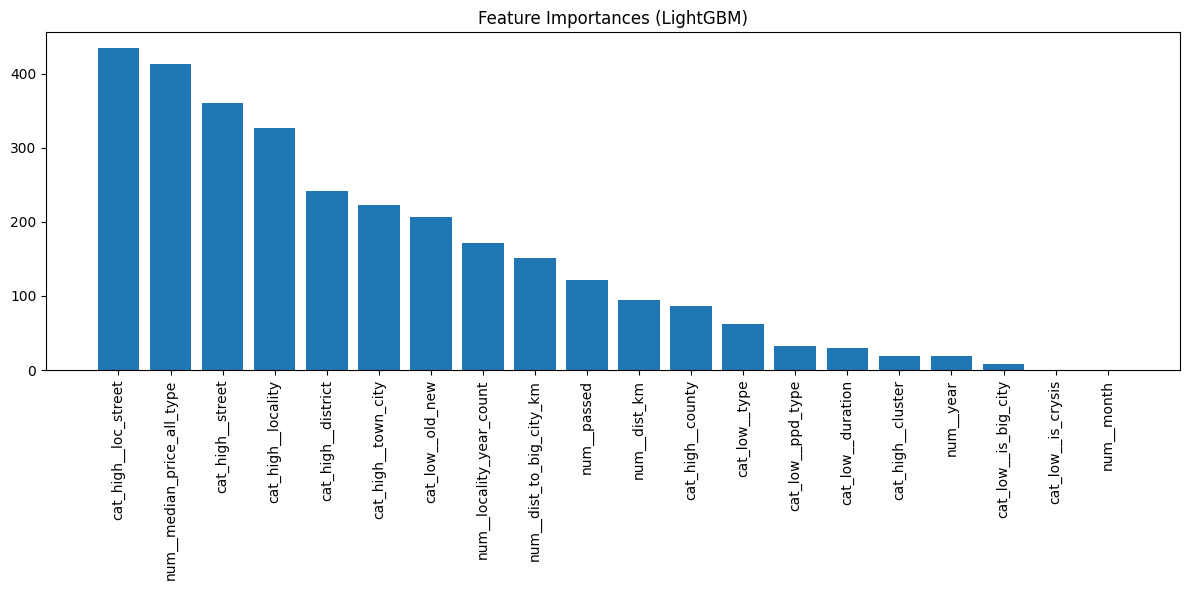

In [31]:
import matplotlib.pyplot as plt
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (LightGBM)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

# --- Создание полного пайплайна (препроцессор + модель) ---
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', xgb)])

pipeline.fit(X_train_processed[all_features], y_train_log_synced)
y_pred_log = pipeline.predict(X_test_processed[all_features])
print_metrics(y_test_log_synced, y_pred_log, label="XGBRegressor")

RMSLE (XGBRegressor): 0.33467
MAE (XGBRegressor): £48,004.52


(np.float64(0.33467469987077153), 48004.5169616178)

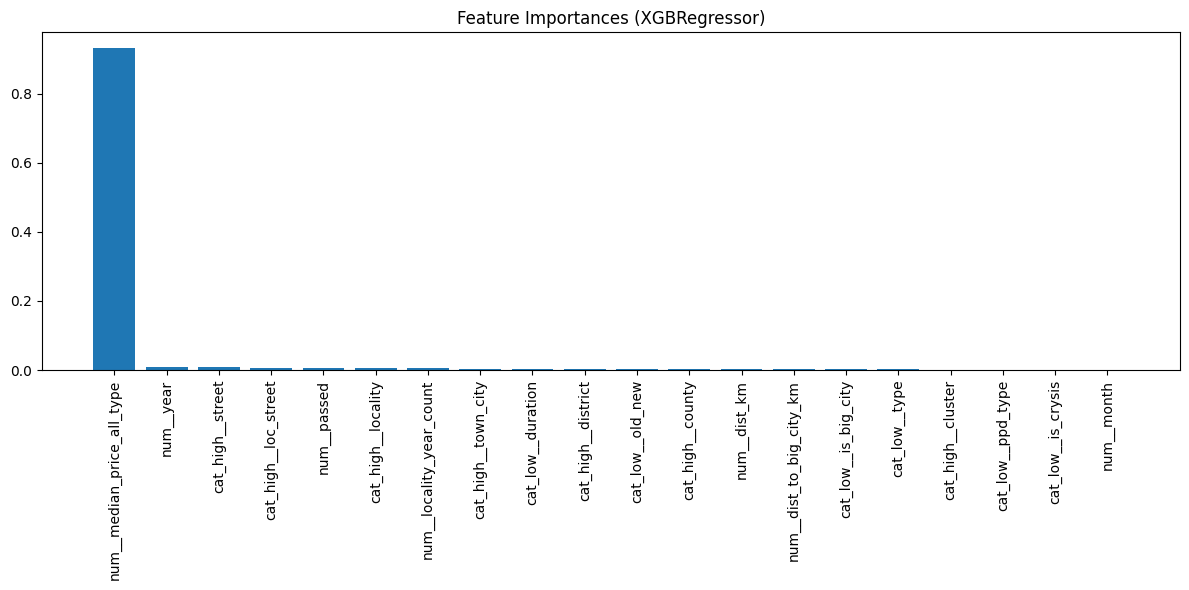

In [33]:
import matplotlib.pyplot as plt
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (XGBRegressor)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()